# Demographics analysis 

In [1]:
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import dataframe_image as dfi
import os
import math
from  matplotlib.ticker import PercentFormatter
sns.set_style("white")
# sns.set_context("notebook")
sns.set_theme(style="ticks", palette="husl")
# set dask dashboard
import dask
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd
from scipy.spatial.transform import Rotation as R
# pd.options.mode.chained_assignment = None  # default='warn'
from dask.distributed import Client
client = Client()  # start distributed scheduler locally.
client

/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 51001 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:51001/status,
Dashboard: http://127.0.0.1:51001/status,Workers: 4
Total threads: 16,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:51002,Workers: 4
Dashboard: http://127.0.0.1:51001/status,Total threads: 16
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:51015,Total threads: 4
Dashboard: http://127.0.0.1:51019/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:51005,


## Load data

In [24]:
# Load the CSV file into a Dask DataFrame
cleaned_df = dd.read_csv('data/EEDA_cleaned.csv', usecols=['uid', 'Condition']).drop_duplicates().compute()

# Get unique entries for uid and Condition
unique_uids = cleaned_df['uid'].tolist()

# The result is now a pandas DataFrame with unique uid and Condition entries
print(unique_uids)

2025-03-28 19:42:43,418 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 0aac2d64d434b46317992fa2f2592020 initialized by task ('shuffle-transfer-0aac2d64d434b46317992fa2f2592020', 28) executed on worker tcp://127.0.0.1:51013
2025-03-28 19:42:48,285 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 0aac2d64d434b46317992fa2f2592020 deactivated due to stimulus 'task-finished-1743187368.2846751'


['6292422bcc12499f8bbb1f99ce2c8045', 'a992bcdab1a34606b910c413d95ecb5c', '841fd4141fce4d6c87838336cbe2bd29', 'a482f246bccf40c5b054211e708b1e47', '87a64715fad54005a7c09869cd308af9', '438d5a2439cd43f0adf46a2d93b562ba', '5f63b1c1abcc4f9996e2bff13a805f05', 'a2ebfaed7fe84041ac60447d4ad4202a', 'a9b1dc903d6c4909a5c71b00f31436d0', 'c374017d0a704427a550e255f1386195', 'f617e0d281db4a6d9e3bb40f1cb62094', '31f30503928e4e2eb0fbb32c52875d36', '3724efdbee3344cfa29b9c162c2ba594', '408a72f8717b4d37b99412742964f1a0', '772b60579d674d02bf8fdd5c62595beb', 'd74daca3e2e24e3686f6e0c33f97365e', '3057ef6f6da54983996afe3dc50fb930', '9723292859554015a1c8b29d496147d9', '57b24549e3fd4c8283bc5be97236c149', '7218deb5dd924db2aea934fcafc9639a', 'd43fe06b996244dfb6219536573f4ea7', '395c9284175b45bab478e9fc535aea2a', '61dafd5932a04da8a02ef42aa7689d8e', 'd6e1298473ee4fe181acf852e0d8d166', 'da2ed790bcf34629b22e30bba95233fb', 'f5c392dbf39643f39d4a0015c1622edd', 'fe2d9be153cf42f38067927cae40177b', '0741fd89e71d4669a8b2cd52d0

In [26]:
# Load the demographics file
demographic_df = dd.read_csv('data/EEDA_Qdata.csv', usecols=['uid', 'age', 'gender', 'Driving licence', 'Driving experience'])

# Filter the DataFrame based on unique_uids
filtered_df = demographic_df[demographic_df['uid'].isin(unique_uids)].compute()
filtered_df

,uid,age,gender,Driving licence,Driving experience
0,797ab82565874e5394135cb8b6b74a6f,33,Weiblich,Ja,22
1,0f887be392684f498dcfa9edf7923fb9,66,intersex,Yes,1
6,9eeca38919f2420cbf03b2cf8e1ec02b,12,Männlich,Nein,0
7,6815a7a58a4c435d8bbed11e34076f74,12,Männlich,Nein,0
10,61dafd5932a04da8a02ef42aa7689d8e,10,Männlich,Nein,0
...,...,...,...,...,...
498,f2e50cd606d84534ba179cf1b44759a8,18,Männlich,Ja,1
506,7218deb5dd924db2aea934fcafc9639a,22,Männlich,Ja,4
514,53e7bc9411994d17910e1fa6ac668984,55,Männlich,Nein,0
515,9f30d624bfe948ec97e395a2a25a57f8,8,Männlich,Nein,9


We merge the cleaned df uids with the demographics uids to know the driving condition for each uid. Some uids will not have demographics.

In [43]:
# Merge the DataFrames on 'uid'
merged_demographics_df = pd.merge(cleaned_df, filtered_df, on='uid', how='left')
merged_demographics_df

,uid,Condition,age,gender,Driving licence,Driving experience
0,6292422bcc12499f8bbb1f99ce2c8045,Manual,NaN,NaN,NaN,NaN
1,a992bcdab1a34606b910c413d95ecb5c,Autonomous,NaN,NaN,NaN,NaN
2,841fd4141fce4d6c87838336cbe2bd29,Manual,11.0,Weiblich,Nein,0.0
3,a482f246bccf40c5b054211e708b1e47,Manual,17.0,Männlich,Nein,0.0
4,87a64715fad54005a7c09869cd308af9,Manual,16.0,Weiblich,Nein,0.0
...,...,...,...,...,...,...
279,75a750169bfc4704a25f993a2152cbc9,Manual,10.0,Weiblich,Nein,0.0
280,af1cad799c1d4041b5fe02f61ef6b45c,Autonomous,11.0,Männlich,Nein,0.0
281,f403396ccc034babbdd8b3bfdac2aaac,Autonomous,13.0,Weiblich,Nein,0.0
282,1a410aaa75ac4908a0946cd86bf23af1,Autonomous,21.0,Männlich,Ja,4.0


In [44]:
merged_demographics_df.groupby(['Condition'])['uid'].nunique()

Condition
Autonomous    153
Manual        131
Name: uid, dtype: int64

## 0. Demographic information formatting 

In [45]:
# Normalize text case
merged_demographics_df['gender'] = merged_demographics_df['gender'].str.lower()
merged_demographics_df['Driving licence'] = merged_demographics_df['Driving licence'].str.lower()

# Replace values in the 'gender' column
gender_replacements = {
    'männlich': 'male',
    'weiblich': 'female',
    'intersex': 'intersex'
}
merged_demographics_df['gender'] = merged_demographics_df['gender'].replace(gender_replacements)

# Replace values in the 'Driving licence' column
licence_replacements = {
    'ja': 'yes',
    'nein': 'no'
}
merged_demographics_df['Driving licence'] = merged_demographics_df['Driving licence'].replace(licence_replacements)
merged_demographics_df

,uid,Condition,age,gender,Driving licence,Driving experience
0,6292422bcc12499f8bbb1f99ce2c8045,Manual,NaN,NaN,NaN,NaN
1,a992bcdab1a34606b910c413d95ecb5c,Autonomous,NaN,NaN,NaN,NaN
2,841fd4141fce4d6c87838336cbe2bd29,Manual,11.0,female,no,0.0
3,a482f246bccf40c5b054211e708b1e47,Manual,17.0,male,no,0.0
4,87a64715fad54005a7c09869cd308af9,Manual,16.0,female,no,0.0
...,...,...,...,...,...,...
279,75a750169bfc4704a25f993a2152cbc9,Manual,10.0,female,no,0.0
280,af1cad799c1d4041b5fe02f61ef6b45c,Autonomous,11.0,male,no,0.0
281,f403396ccc034babbdd8b3bfdac2aaac,Autonomous,13.0,female,no,0.0
282,1a410aaa75ac4908a0946cd86bf23af1,Autonomous,21.0,male,yes,4.0


## 1. UIDs without demographic info

In [46]:
# Identify participants without demographic info
missing_info_df = merged_demographics_df[merged_demographics_df['age'].isna()][['uid', 'Condition']]
# Number of participants without demographics
num_missing = missing_info_df['uid'].nunique()
print(f"There are {num_missing} participants without demographic information.")
# Participants without demographics by condition
print(missing_info_df.groupby(['Condition'])['uid'].nunique())

There are 116 participants without demographic information.
Condition
Autonomous    66
Manual        50
Name: uid, dtype: int64


## 2. UIDs with demographic info statistics

In [47]:
# Identify participants with demographic info
missing_info_df = merged_demographics_df[~merged_demographics_df['age'].isna()][['uid', 'Condition', 'gender']]
# Number of participants with demographics
num_missing = missing_info_df['uid'].nunique()
print(f"There are {num_missing} participants with demographic information.")
# Participants with demographics by condition
print(missing_info_df.groupby(['gender','Condition'])['uid'].nunique())

There are 168 participants with demographic information.
gender    Condition 
female    Autonomous    20
          Manual        17
intersex  Autonomous     1
          Manual         5
male      Autonomous    66
          Manual        59
Name: uid, dtype: int64


In [48]:
# Group by 'uid' and take the first occurrence to ensure unique uids
unique_participants = merged_demographics_df.groupby('uid').first().dropna(subset=['age'])
# unique_participants.dropna(subset=['age'])
# Compute gender and driving licence counts
gender_counts = unique_participants['gender'].value_counts()
driving_licence_counts = unique_participants['Driving licence'].value_counts()

# Compute mean and standard deviation for age and driving experience
age_stats = unique_participants['age'].agg(['mean', 'std'])
driving_experience_stats = unique_participants['Driving experience'].agg(['mean', 'std'])

# Print the computed statistics
print("Gender Counts:")
print(gender_counts, "\n")

print("Driving Licence Counts:")
print(driving_licence_counts, "\n")

print("Age Statistics:")
print(age_stats, "\n")

print("Driving Experience Statistics:")
print(driving_experience_stats)

Gender Counts:
gender
male        125
female       37
intersex      6
Name: count, dtype: int64 

Driving Licence Counts:
Driving licence
no     93
yes    75
Name: count, dtype: int64 

Age Statistics:
mean    23.410714
std     15.602215
Name: age, dtype: float64 

Driving Experience Statistics:
mean     7.476190
std     12.416887
Name: Driving experience, dtype: float64


## 3. Visualize demographics

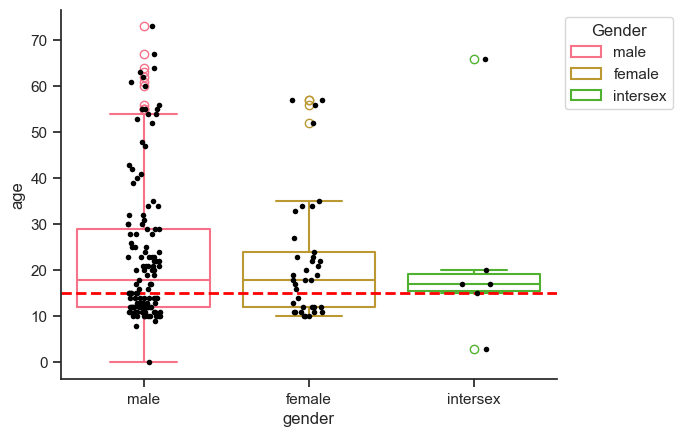

In [49]:
fig, ax = plt.subplots(1,1)
sns.boxplot(x='gender', y='age', data=unique_participants, fill=False, hue='gender', ax= ax, legend=True)
sns.stripplot(x='gender', y='age',data=unique_participants, color='k', legend=True, s=4, ax=ax)
# Add a horizontal line at 15 years
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='Age 15 Threshold')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Gender')
sns.despine()
plt.show()